# Exploration and analysis of raw datasets

Datasets: `performances`, `players`, `transfers`, `injuries` et `national_performances` ;

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [8]:
cwd = Path.cwd().resolve()
project_root = cwd.parents[1]

raw_dir = project_root / "transferability" / "data" / "raw"

print("project_root:", project_root)
print("raw_dir:", raw_dir)
print("csv files:")
for csv_path in sorted(raw_dir.glob("*.csv")):
    print("-", csv_path.name)

project_root: /Users/yannis/as1
raw_dir: /Users/yannis/as1/transferability/data/raw
csv files:
- injuries.csv
- national_performances.csv
- performances.csv
- players.csv
- transfers.csv


## Loading data

In [9]:
players = pd.read_csv(
    raw_dir / "players.csv",
    parse_dates=[
        "date_of_birth",
        "contract_expires",
        "date_of_last_contract_extension",
        "contract_there_expires",
        "date_of_death",
    ],
)

transfers = pd.read_csv(raw_dir / "transfers.csv", parse_dates=["transfer_date"])
performances = pd.read_csv(raw_dir / "performances.csv")
injuries = pd.read_csv(raw_dir / "injuries.csv", parse_dates=["from_date", "end_date"])
national_performances = pd.read_csv(raw_dir / "national_performances.csv", parse_dates=["date_debut"])

tables = {
    "players": players,
    "transfers": transfers,
    "performances": performances,
    "injuries": injuries,
    "national_performances": national_performances,
}

In [10]:
overview_rows = []

for name, df in tables.items():
    overview_rows.append(
        {
            "table": name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "unique_players": df["player_id"].nunique() if "player_id" in df.columns else np.nan,
            "missing_cells_rate": df.isna().mean().mean(),
        }
    )

overview = pd.DataFrame(overview_rows).sort_values("rows", ascending=False)
overview

,table,rows,columns,unique_players,missing_cells_rate
2,performances,123885,19,8706,0.105263
1,transfers,33864,8,9519,0.000000
3,injuries,27470,8,5449,0.001716
4,national_performances,12881,5,4682,0.000000
0,players,10000,19,10000,0.231205


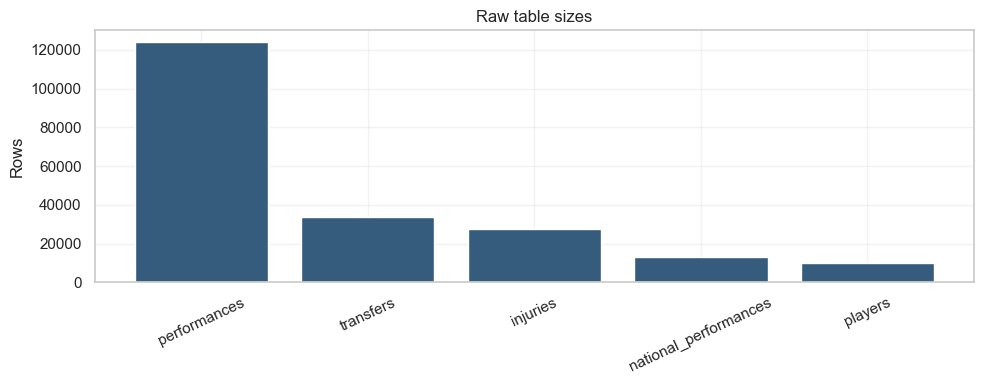

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(overview["table"], overview["rows"], color="#355C7D")
ax.set_title("Raw table sizes")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()

## First look

In [12]:
for name, df in tables.items():
    print("" + "=" * 90)
    print(name.upper(), df.shape)
    print(df.dtypes.astype(str).to_string())
    display(df.head(3))

PLAYERS (10000, 19)
player_id                                   int64
player_name                                   str
date_of_birth                      datetime64[us]
country_of_birth                              str
market_value                                int64
citizenship                                   str
second_citizenship                            str
is_eu                                        bool
main_position                                 str
position                                      str
foot                                          str
current_club_name                             str
contract_expires                   datetime64[us]
date_of_last_contract_extension    datetime64[us]
is_on_loan                                   bool
contract_there_expires             datetime64[us]
date_of_death                      datetime64[us]
international_team                            str
current_league_name                           str


,player_id,player_name,date_of_birth,country_of_birth,market_value,citizenship,second_citizenship,is_eu,main_position,position,foot,current_club_name,contract_expires,date_of_last_contract_extension,is_on_loan,contract_there_expires,date_of_death,international_team,current_league_name
0,688079,Leandro Lima,2001-12-26,Brazil,125000,Brazil,NaN,False,Attack,Right Winger,Right,---,NaT,NaT,False,NaT,2025-03-30,NaN,NaN
1,1042907,Oliver Klemensen,2006-03-01,NaN,25000,Denmark,NaN,True,Defense,Centre-Back,Right,07 Vestur,NaT,NaT,False,NaT,NaT,Denmark U19,Betri-deildin
2,201994,Sonni Nattestad,1994-08-05,Faroe Islands,50000,Faroe Islands,NaN,False,Defense,Centre-Back,Left,07 Vestur,2026-10-31,2024-11-05,False,NaT,NaT,Faroe Islands,Betri-deildin


TRANSFERS (33864, 8)
player_id                     int64
season_name                     str
transfer_date        datetime64[us]
from_team_name                  str
to_team_name                    str
transfer_type                   str
value_at_transfer             int64
transfer_fee                  int64


,player_id,season_name,transfer_date,from_team_name,to_team_name,transfer_type,value_at_transfer,transfer_fee
0,1000153,22/23,2022-07-01,FC Sochaux U19,San Fernando B,Transfer,0,0
1,1000153,25/26,2025-07-11,San Fernando B,CA Antoniano,Transfer,0,0
2,1000630,25/26,2026-06-30,CD Mirandés,Valencia B,Return from loan,300000,0


PERFORMANCES (123885, 19)
player_id                int64
season_name                str
competition_id             str
competition_name           str
team_name                  str
nb_in_group              int64
nb_on_pitch              int64
goals                    int64
assists                float64
own_goals                int64
subed_in                 int64
subed_out                int64
yellow_cards             int64
second_yellow_cards      int64
direct_red_cards         int64
penalty_goals          float64
minutes_played           int64
goals_conceded         float64
clean_sheets           float64


,player_id,season_name,competition_id,competition_name,team_name,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
0,1000630,24/25,E4G3,Segunda Federación - Gr. III,Valencia Mestalla,28,23,3,2.0,0,11,11,2,0,1,1.0,1115,NaN,NaN
1,1000630,24/25,CDR,Copa del Rey,Valencia CF,1,1,0,0.0,0,1,0,0,0,0,0.0,2,NaN,NaN
2,1000630,23/24,E4G3,Segunda Federación - Gr. III,Valencia Mestalla,1,0,0,0.0,0,0,0,0,0,0,0.0,0,NaN,NaN


INJURIES (27470, 8)
player_id                 int64
season_id                 int64
injury_reason               str
is_virus                   bool
from_date        datetime64[us]
end_date         datetime64[us]
days_missed             float64
games_missed            float64


,player_id,season_id,injury_reason,is_virus,from_date,end_date,days_missed,games_missed
0,254254,2016,Muscle injury,False,2016-01-09,2016-02-04,27.0,8.0
1,254254,2016,Ankle injury,False,2016-06-14,2016-07-04,21.0,4.0
2,254254,2020,Torn lateral knee ligament,False,2021-01-30,2021-07-31,183.0,32.0


NATIONAL_PERFORMANCES (12881, 5)
player_id                int64
team_name                  str
games_played             int64
goals_scored             int64
date_debut      datetime64[us]


,player_id,team_name,games_played,goals_scored,date_debut
0,1097141,Wales U16,1,0,2022-10-05
1,109816,Hungary U19,1,0,2010-09-08
2,109816,Hungary U18,1,2,2009-12-14


## Missing values

In [13]:
for name, df in tables.items():
    missing = pd.DataFrame(
        {
            "column": df.columns,
            "missing_count": df.isna().sum().values,
            "missing_rate": df.isna().mean().values,
            "dtype": df.dtypes.astype(str).values,
        }
    ).sort_values(["missing_rate", "missing_count"], ascending=False)

    print("" + "=" * 90)
    print(name.upper())
    display(missing.head(12))

PLAYERS


,column,missing_count,missing_rate,dtype
16,date_of_death,9999,0.9999,datetime64[us]
15,contract_there_expires,9304,0.9304,datetime64[us]
13,date_of_last_contract_extension,8233,0.8233,datetime64[us]
6,second_citizenship,7465,0.7465,str
17,international_team,4955,0.4955,str
12,contract_expires,1308,0.1308,datetime64[us]
10,foot,1294,0.1294,str
3,country_of_birth,1042,0.1042,str
18,current_league_name,290,0.0290,str
9,position,35,0.0035,str


TRANSFERS


,column,missing_count,missing_rate,dtype
0,player_id,0,0.0,int64
1,season_name,0,0.0,str
2,transfer_date,0,0.0,datetime64[us]
3,from_team_name,0,0.0,str
4,to_team_name,0,0.0,str
5,transfer_type,0,0.0,str
6,value_at_transfer,0,0.0,int64
7,transfer_fee,0,0.0,int64


PERFORMANCES


,column,missing_count,missing_rate,dtype
17,goals_conceded,112828,0.910748,float64
18,clean_sheets,112828,0.910748,float64
8,assists,11057,0.089252,float64
15,penalty_goals,11057,0.089252,float64
0,player_id,0,0.000000,int64
1,season_name,0,0.000000,str
2,competition_id,0,0.000000,str
3,competition_name,0,0.000000,str
4,team_name,0,0.000000,str
5,nb_in_group,0,0.000000,int64


INJURIES


,column,missing_count,missing_rate,dtype
5,end_date,365,0.013287,datetime64[us]
4,from_date,4,0.000146,datetime64[us]
6,days_missed,4,0.000146,float64
7,games_missed,4,0.000146,float64
0,player_id,0,0.000000,int64
1,season_id,0,0.000000,int64
2,injury_reason,0,0.000000,str
3,is_virus,0,0.000000,bool


NATIONAL_PERFORMANCES


,column,missing_count,missing_rate,dtype
0,player_id,0,0.0,int64
1,team_name,0,0.0,str
2,games_played,0,0.0,int64
3,goals_scored,0,0.0,int64
4,date_debut,0,0.0,datetime64[us]


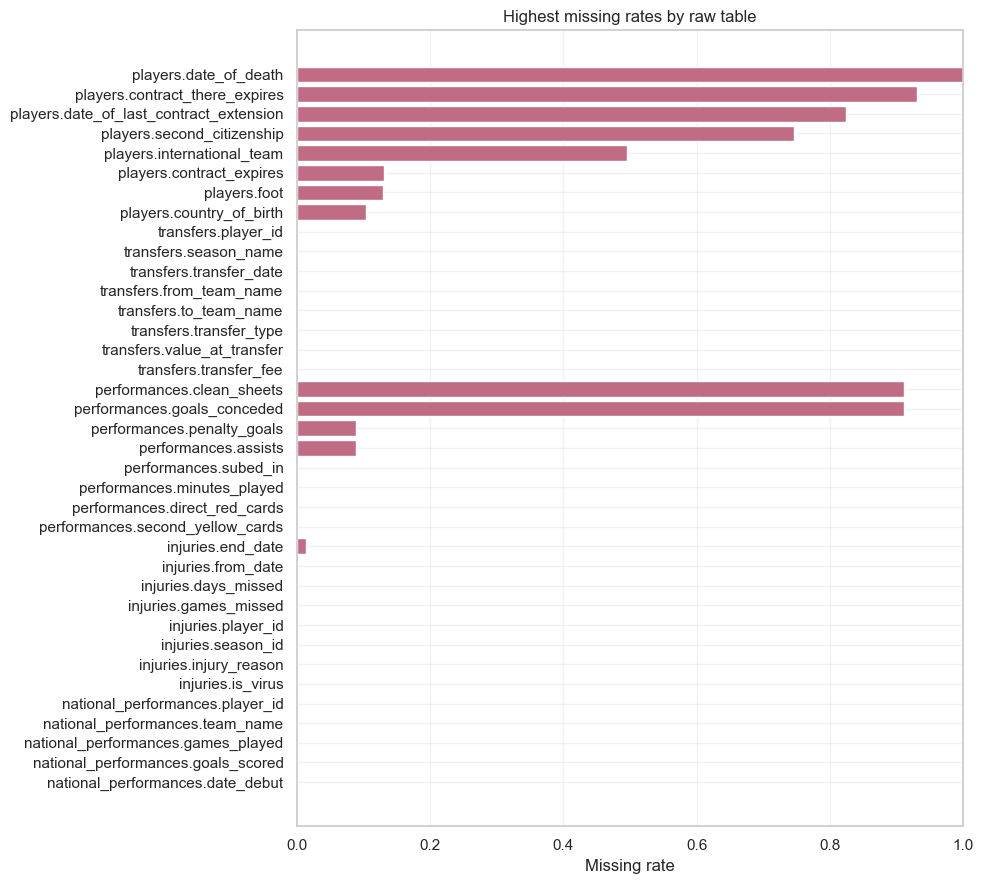

In [14]:
missing_matrix = []
missing_labels = []

for name, df in tables.items():
    top_missing_columns = df.isna().mean().sort_values(ascending=False).head(8)
    for column_name, missing_rate in top_missing_columns.items():
        missing_labels.append(f"{name}.{column_name}")
        missing_matrix.append(missing_rate)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(missing_labels[::-1], missing_matrix[::-1], color="#C06C84")
ax.set_xlim(0, 1)
ax.set_title("Highest missing rates by raw table")
ax.set_xlabel("Missing rate")
plt.tight_layout()

## Duplicates and keys

In [15]:
duplicate_checks = []

duplicate_checks.append(
    {
        "table": "players",
        "full_duplicate_rows": players.duplicated().sum(),
        "business_key_duplicates": players.duplicated(["player_id"]).sum(),
        "business_key": "player_id",
    }
)

duplicate_checks.append(
    {
        "table": "transfers",
        "full_duplicate_rows": transfers.duplicated().sum(),
        "business_key_duplicates": transfers.duplicated(
            ["player_id", "season_name", "transfer_date", "from_team_name", "to_team_name", "transfer_type"]
        ).sum(),
        "business_key": "player_id + season + date + from + to + type",
    }
)

duplicate_checks.append(
    {
        "table": "performances",
        "full_duplicate_rows": performances.duplicated().sum(),
        "business_key_duplicates": performances.duplicated(
            ["player_id", "season_name", "competition_id", "team_name"]
        ).sum(),
        "business_key": "player_id + season + competition + team",
    }
)

duplicate_checks.append(
    {
        "table": "injuries",
        "full_duplicate_rows": injuries.duplicated().sum(),
        "business_key_duplicates": injuries.duplicated(
            ["player_id", "season_id", "injury_reason", "from_date"]
        ).sum(),
        "business_key": "player_id + season_id + reason + from_date",
    }
)

duplicate_checks.append(
    {
        "table": "national_performances",
        "full_duplicate_rows": national_performances.duplicated().sum(),
        "business_key_duplicates": national_performances.duplicated(
            ["player_id", "team_name", "date_debut"]
        ).sum(),
        "business_key": "player_id + team_name + date_debut",
    }
)

pd.DataFrame(duplicate_checks)

,table,full_duplicate_rows,business_key_duplicates,business_key
0,players,0,0,player_id
1,transfers,5,5,player_id + season + date + from + to + type
2,performances,0,0,player_id + season + competition + team
3,injuries,6,15,player_id + season_id + reason + from_date
4,national_performances,4,4,player_id + team_name + date_debut


## Table `players`

In [16]:
players_summary = pd.DataFrame(
    [
        ["rows", players.shape[0]],
        ["unique players", players["player_id"].nunique()],
        ["missing date_of_birth", players["date_of_birth"].isna().sum()],
        ["missing main_position", players["main_position"].isna().sum()],
        ["missing position", players["position"].isna().sum()],
        ["missing current_club_name", players["current_club_name"].isna().sum()],
        ["missing contract_expires", players["contract_expires"].isna().sum()],
        ["missing current_league_name", players["current_league_name"].isna().sum()],
    ],
    columns=["metric", "value"],
)

players_summary

,metric,value
0,rows,10000
1,unique players,10000
2,missing date_of_birth,3
3,missing main_position,0
4,missing position,35
5,missing current_club_name,0
6,missing contract_expires,1308
7,missing current_league_name,290


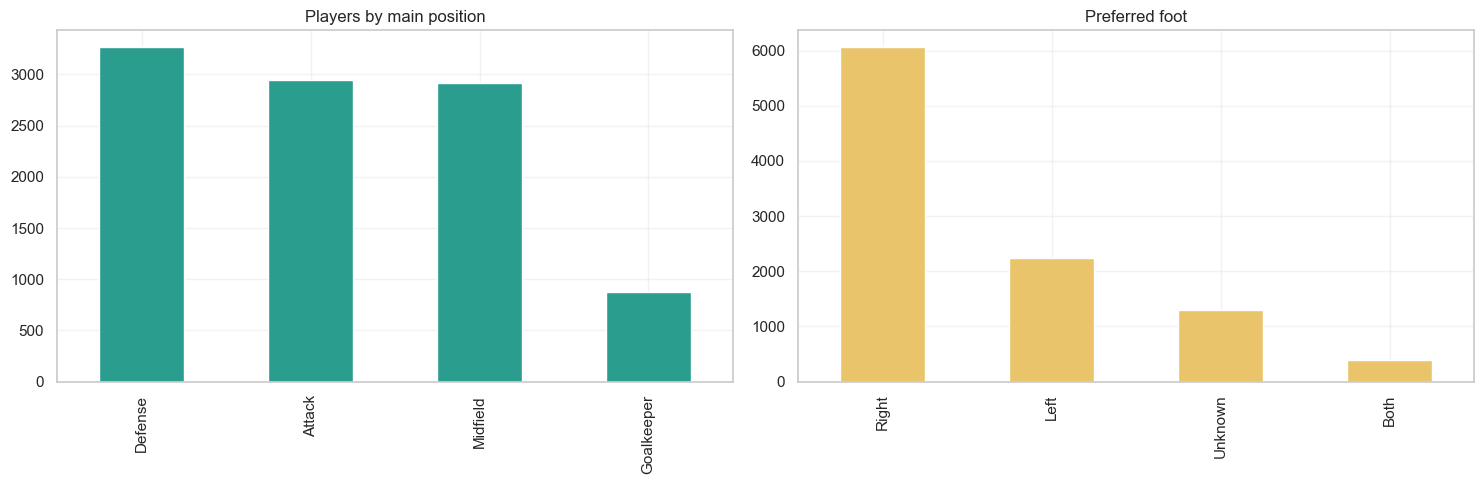

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

players["main_position"].fillna("Unknown").value_counts().plot(
    kind="bar",
    ax=axes[0],
    color="#2A9D8F",
)
axes[0].set_title("Players by main position")
axes[0].set_xlabel("")

players["foot"].fillna("Unknown").value_counts().plot(
    kind="bar",
    ax=axes[1],
    color="#E9C46A",
)
axes[1].set_title("Preferred foot")
axes[1].set_xlabel("")

plt.tight_layout()

In [18]:
players["citizenship"].fillna("Unknown").value_counts().head(20)

citizenship
Italy             1691
Spain             1406
Germany            642
England            456
Brazil             374
Argentina          329
France             279
Netherlands        201
Portugal           198
Greece             198
Hungary            159
Bulgaria           152
Denmark            140
Belarus            140
Scotland           115
Wales              114
Uruguay            107
Czech Republic     104
Nigeria            102
Colombia            97
Name: count, dtype: int64

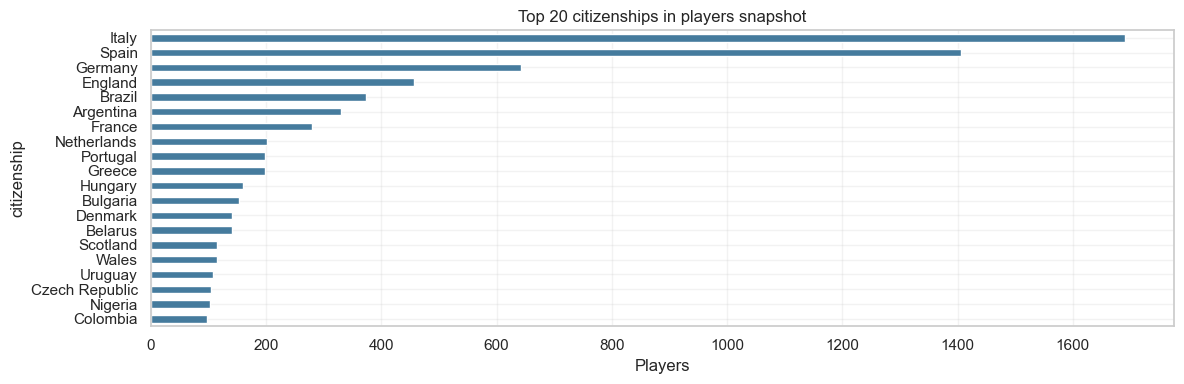

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
players["citizenship"].fillna("Unknown").value_counts().head(20).sort_values().plot(
    kind="barh",
    ax=ax,
    color="#457B9D",
)
ax.set_title("Top 20 citizenships in players snapshot")
ax.set_xlabel("Players")
plt.tight_layout()

In [20]:
players["market_value"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    1.000000e+04
mean     1.587106e+06
std      6.217828e+06
min      1.000000e+04
25%      7.500000e+04
50%      2.000000e+05
75%      5.000000e+05
90%      2.500000e+06
95%      7.000000e+06
99%      3.000000e+07
max      1.300000e+08
Name: market_value, dtype: float64

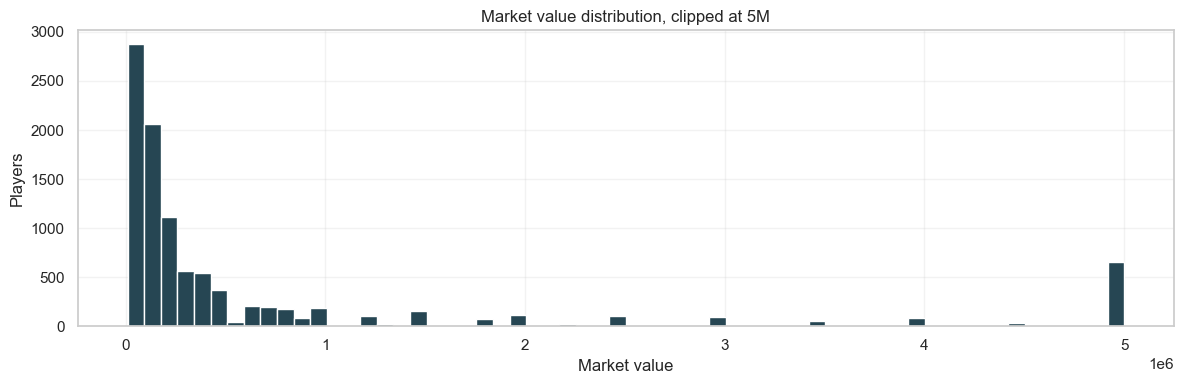

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
players.loc[players["market_value"].fillna(0) > 0, "market_value"].clip(upper=5_000_000).hist(
    bins=60,
    ax=ax,
    color="#264653",
)
ax.set_title("Market value distribution, clipped at 5M")
ax.set_xlabel("Market value")
ax.set_ylabel("Players")
plt.tight_layout()

## Table `performances`

In [22]:
performances[[
    "nb_in_group",
    "nb_on_pitch",
    "goals",
    "assists",
    "subed_in",
    "subed_out",
    "yellow_cards",
    "direct_red_cards",
    "minutes_played",
]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])

,nb_in_group,nb_on_pitch,goals,assists,subed_in,subed_out,yellow_cards,direct_red_cards,minutes_played
count,123885.000000,123885.000000,123885.000000,112828.000000,123885.000000,123885.000000,123885.000000,123885.000000,123885.000000
mean,10.307672,8.479081,0.955903,0.641383,1.968777,2.313234,1.186826,0.033757,583.212762
std,11.195065,10.117244,2.283777,1.445632,3.411940,3.857787,1.977030,0.188092,767.029968
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,87.000000
50%,5.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,210.000000
75%,17.000000,13.000000,1.000000,1.000000,2.000000,3.000000,2.000000,0.000000,810.000000
90%,30.000000,26.000000,3.000000,2.000000,6.000000,7.000000,4.000000,0.000000,1850.000000
99%,38.000000,36.000000,11.000000,7.000000,16.000000,18.000000,9.000000,1.000000,3007.160000
max,46.000000,46.000000,44.000000,22.000000,32.000000,31.000000,17.000000,3.000000,4140.000000


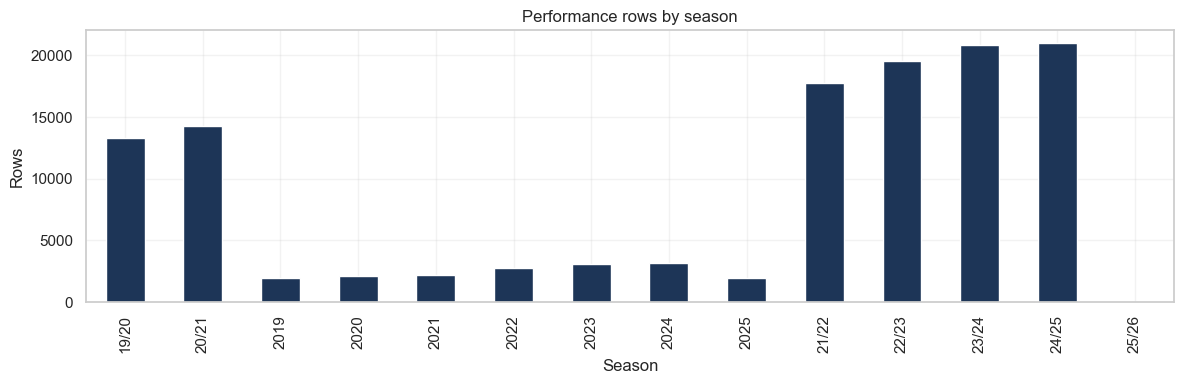

In [23]:
season_counts = performances["season_name"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
season_counts.plot(kind="bar", ax=ax, color="#1D3557")
ax.set_title("Performance rows by season")
ax.set_xlabel("Season")
ax.set_ylabel("Rows")
plt.tight_layout()

In [24]:
top_competitions = (
    performances.groupby("competition_name", as_index=False)
    .agg(
        rows=("player_id", "size"),
        players=("player_id", "nunique"),
        teams=("team_name", "nunique"),
        total_minutes=("minutes_played", "sum"),
    )
    .sort_values("rows", ascending=False)
)

top_competitions.head(25)

,competition_name,rows,players,teams,total_minutes
292,Copa del Rey,2835,1151,182,332653
366,FA Cup,2545,839,132,310340
428,Italy Cup,2239,939,103,204452
335,EFL Cup,2229,791,100,226427
300,Coppa Serie D,1919,852,318,203204
299,Coppa Serie C,1873,854,117,184521
320,DFB-Pokal,1738,604,90,194672
357,Europa League,1542,979,125,487921
1191,UEFA Champions League,1447,712,76,491644
336,EFL Trophy,1381,527,103,221427


In [25]:
player_season_minutes = (
    performances.groupby(["player_id", "season_name"], as_index=False)
    .agg(
        minutes_played=("minutes_played", "sum"),
        matches_played=("nb_on_pitch", "sum"),
        competitions=("competition_id", "nunique"),
        teams=("team_name", "nunique"),
    )
)

player_season_minutes.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,player_id,minutes_played,matches_played,competitions,teams
count,4.765900e+04,47659.000000,47659.000000,47659.000000,47659.000000
mean,5.039062e+05,1516.005644,22.040559,2.558132,1.285822
std,2.836179e+05,1024.145683,12.591216,1.279482,0.537809
min,2.150000e+02,0.000000,0.000000,1.000000,1.000000
25%,2.778090e+05,632.000000,12.000000,2.000000,1.000000
50%,4.636050e+05,1467.000000,23.000000,2.000000,1.000000
75%,6.996790e+05,2276.000000,32.000000,3.000000,1.000000
90%,9.269470e+05,2893.000000,37.000000,4.000000,2.000000
95%,1.020749e+06,3239.100000,41.000000,5.000000,2.000000
99%,1.175538e+06,3981.000000,49.000000,6.000000,3.000000


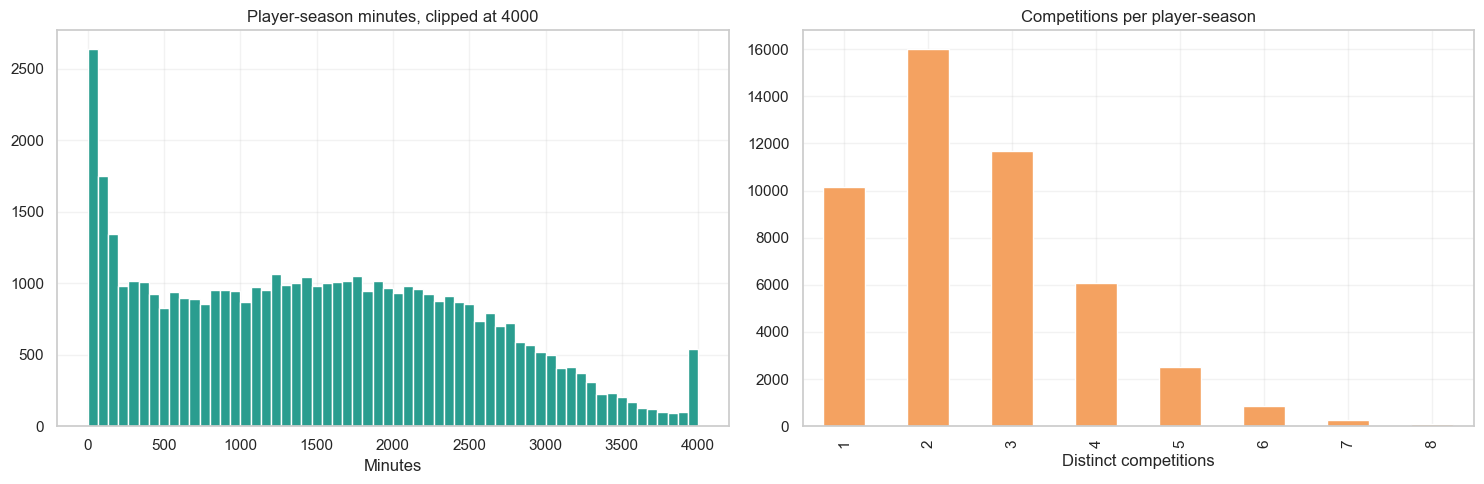

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

player_season_minutes["minutes_played"].clip(upper=4_000).hist(
    bins=60,
    ax=axes[0],
    color="#2A9D8F",
)
axes[0].set_title("Player-season minutes, clipped at 4000")
axes[0].set_xlabel("Minutes")

player_season_minutes["competitions"].clip(upper=8).value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    color="#F4A261",
)
axes[1].set_title("Competitions per player-season")
axes[1].set_xlabel("Distinct competitions")

plt.tight_layout()

Les joueurs sont souvent presents dans plusieurs competitions sur une meme saison. Il faudra donc choisir plus tard une equipe principale / competition principale avec une regle objective, probablement les minutes.

## Table `transfers`

In [27]:
transfers_summary = pd.DataFrame(
    [
        ["rows", transfers.shape[0]],
        ["unique players", transfers["player_id"].nunique()],
        ["unique from teams", transfers["from_team_name"].nunique()],
        ["unique to teams", transfers["to_team_name"].nunique()],
        ["zero value_at_transfer", (transfers["value_at_transfer"].fillna(0) == 0).sum()],
        ["zero transfer_fee", (transfers["transfer_fee"].fillna(0) == 0).sum()],
    ],
    columns=["metric", "value"],
)

transfers_summary

,metric,value
0,rows,33864
1,unique players,9519
2,unique from teams,6311
3,unique to teams,5131
4,zero value_at_transfer,7985
5,zero transfer_fee,31203


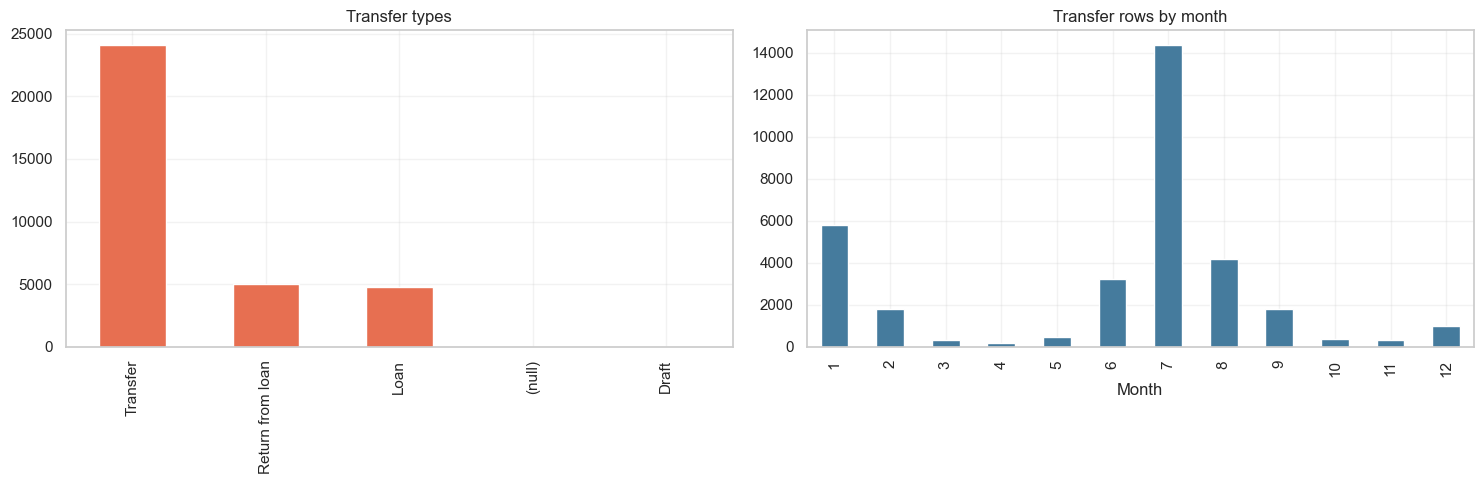

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

transfers["transfer_type"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color="#E76F51",
)
axes[0].set_title("Transfer types")
axes[0].set_xlabel("")

transfers["transfer_date"].dt.month.value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    color="#457B9D",
)
axes[1].set_title("Transfer rows by month")
axes[1].set_xlabel("Month")

plt.tight_layout()

In [29]:
transfer_year_month = transfers.copy()
transfer_year_month["year"] = transfer_year_month["transfer_date"].dt.year
transfer_year_month["month"] = transfer_year_month["transfer_date"].dt.month

transfer_month_pivot = pd.crosstab(transfer_year_month["year"], transfer_year_month["month"])
transfer_month_pivot.tail(10)

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2022,0,0,0,0,0,0,3588,878,357,79,54,256
2023,1463,290,119,59,140,793,3577,1022,487,84,81,240
2024,1355,518,101,58,120,777,3599,1190,373,103,88,203
2025,1454,575,109,59,91,860,3554,1097,608,135,102,221
2026,1506,430,1,2,98,804,24,0,0,0,3,73
2027,2,0,0,0,0,3,0,0,0,0,0,0
2030,0,0,0,0,0,1,0,0,0,0,0,0


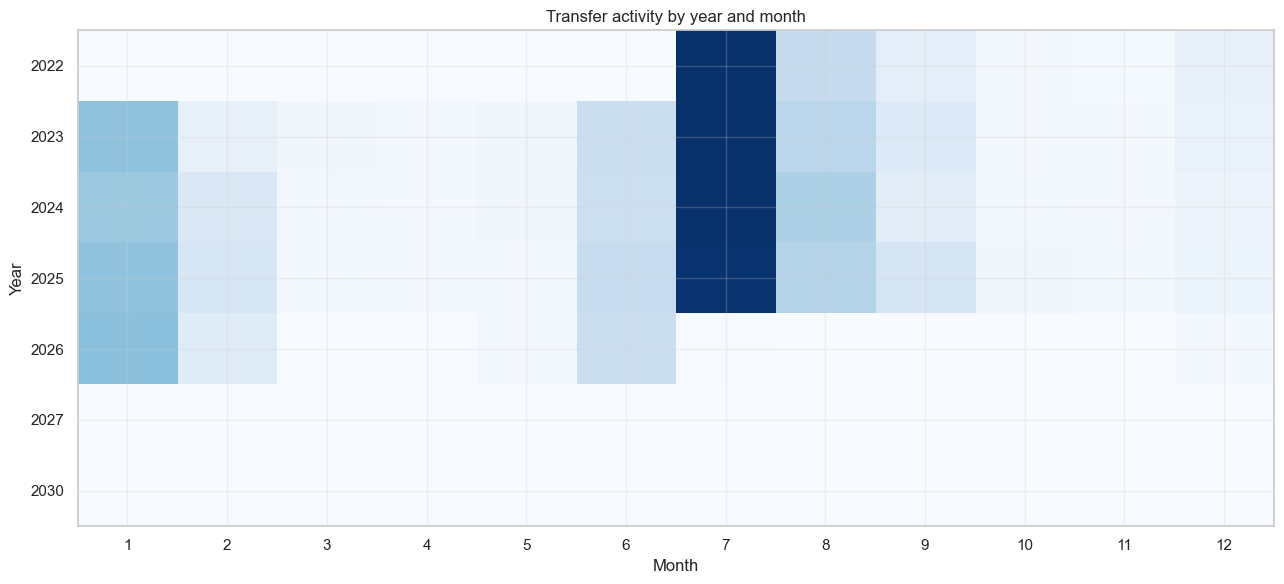

In [30]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(transfer_month_pivot.fillna(0).values, aspect="auto", cmap="Blues")
ax.set_title("Transfer activity by year and month")
ax.set_yticks(range(len(transfer_month_pivot.index)))
ax.set_yticklabels(transfer_month_pivot.index)
ax.set_xticks(range(len(transfer_month_pivot.columns)))
ax.set_xticklabels(transfer_month_pivot.columns)
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()

In [40]:
category_tokens = "U19|U18|U17|U21|U23| B$| II$| III$|Youth|Reserve|Mestalla|Primavera"

category_like_moves = transfers.loc[
    transfers["from_team_name"].astype(str).str.contains(category_tokens, case=False, regex=True)
    | transfers["to_team_name"].astype(str).str.contains(category_tokens, case=False, regex=True)
].copy()

print(len(category_like_moves))

category_like_moves[[
    "player_id",
    "season_name",
    "transfer_date",
    "from_team_name",
    "to_team_name",
    "transfer_type",
]].head(25)

7685


,player_id,season_name,transfer_date,from_team_name,to_team_name,transfer_type
0,1000153,22/23,2022-07-01,FC Sochaux U19,San Fernando B,Transfer
1,1000153,25/26,2025-07-11,San Fernando B,CA Antoniano,Transfer
2,1000630,25/26,2026-06-30,CD Mirandés,Valencia B,Return from loan
3,1000630,25/26,2025-09-01,Valencia B,CD Mirandés,Loan
4,1000630,24/25,2024-07-01,Valencia U19,Valencia B,Transfer
5,1000630,23/24,2023-07-01,Valencia U18,Valencia U19,Transfer
6,1000630,22/23,2022-07-01,Levante UD Yout,Valencia U18,Transfer
7,1000698,22/23,2023-03-08,FC Minsk II,BK Maxline,Transfer
14,1001156,22/23,2022-07-01,Podbrezova U19,Pohronie,Transfer
16,1001362,23/24,2024-06-30,Aalborg BK,Sydney FC II,Return from loan


A lot of categories moves... (to clean in the FE)

## Tables `injuries` ands `national_performances`

Historical data

In [32]:
injury_summary = pd.DataFrame(
    [
        ["rows", injuries.shape[0]],
        ["unique players", injuries["player_id"].nunique()],
        ["missing from_date", injuries["from_date"].isna().sum()],
        ["missing end_date", injuries["end_date"].isna().sum()],
        ["median days_missed", injuries["days_missed"].median()],
        ["median games_missed", injuries["games_missed"].median()],
    ],
    columns=["metric", "value"],
)

national_summary = pd.DataFrame(
    [
        ["rows", national_performances.shape[0]],
        ["unique players", national_performances["player_id"].nunique()],
        ["unique teams", national_performances["team_name"].nunique()],
        ["median games_played", national_performances["games_played"].median()],
        ["median goals_scored", national_performances["goals_scored"].median()],
    ],
    columns=["metric", "value"],
)

display(injury_summary)
display(national_summary)

,metric,value
0,rows,27470.0
1,unique players,5449.0
2,missing from_date,4.0
3,missing end_date,365.0
4,median days_missed,19.0
5,median games_missed,2.0


,metric,value
0,rows,12881.0
1,unique players,4682.0
2,unique teams,840.0
3,median games_played,5.0
4,median goals_scored,0.0


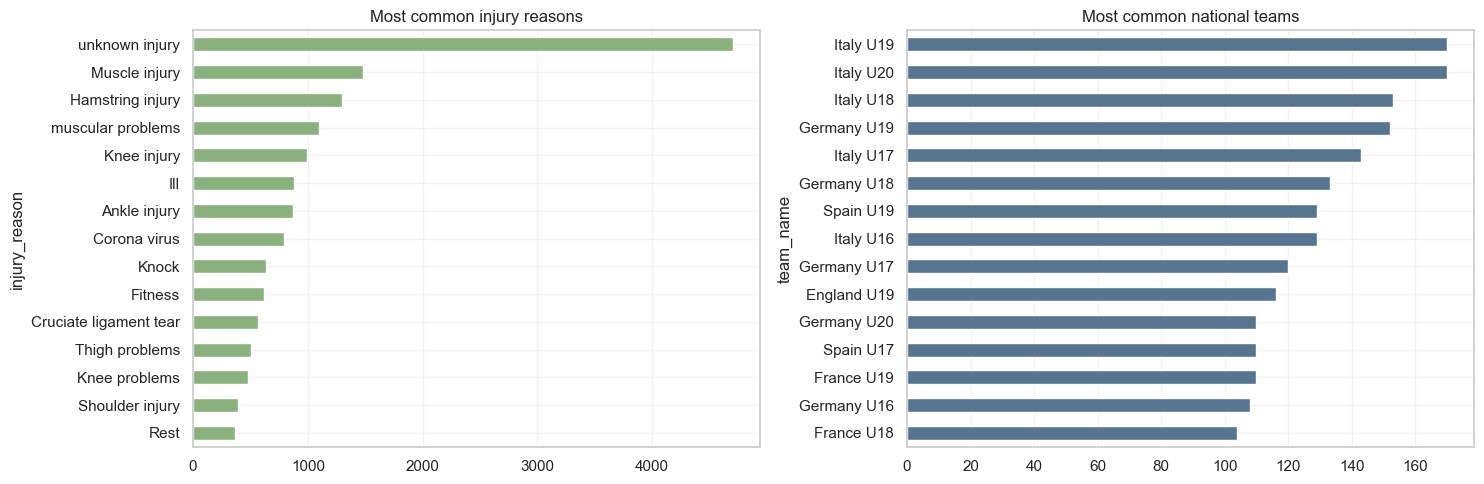

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

injuries["injury_reason"].value_counts().head(15).sort_values().plot(
    kind="barh",
    ax=axes[0],
    color="#8AB17D",
)
axes[0].set_title("Most common injury reasons")

national_performances["team_name"].value_counts().head(15).sort_values().plot(
    kind="barh",
    ax=axes[1],
    color="#577590",
)
axes[1].set_title("Most common national teams")

plt.tight_layout()

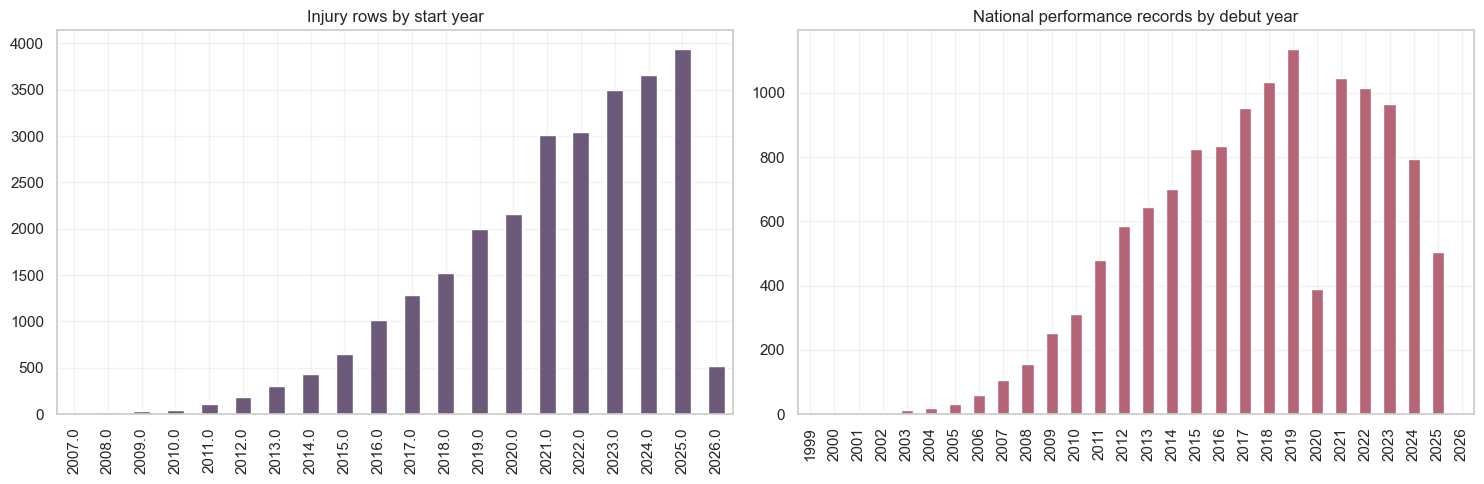

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

injuries["from_date"].dt.year.value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    color="#6D597A",
)
axes[0].set_title("Injury rows by start year")
axes[0].set_xlabel("")

national_performances["date_debut"].dt.year.value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    color="#B56576",
)
axes[1].set_title("National performance records by debut year")
axes[1].set_xlabel("")

plt.tight_layout()

## Couverture entre les sources

`performances` sera probablement la base de l'univers joueur-saison. Je veux donc savoir combien de joueurs de cette table sont retrouves dans les autres sources.

In [35]:
performance_player_ids = set(performances["player_id"].unique())

coverage = pd.DataFrame(
    [
        ["players", len(performance_player_ids & set(players["player_id"].unique()))],
        ["transfers", len(performance_player_ids & set(transfers["player_id"].unique()))],
        ["injuries", len(performance_player_ids & set(injuries["player_id"].unique()))],
        ["national_performances", len(performance_player_ids & set(national_performances["player_id"].unique()))],
    ],
    columns=["source", "covered_players_from_performances"],
)

coverage["performance_player_universe"] = len(performance_player_ids)
coverage["coverage_rate"] = coverage["covered_players_from_performances"] / coverage["performance_player_universe"]
coverage

,source,covered_players_from_performances,performance_player_universe,coverage_rate
0,players,7711,8706,0.885711
1,transfers,7336,8706,0.842637
2,injuries,4534,8706,0.520790
3,national_performances,3848,8706,0.441994


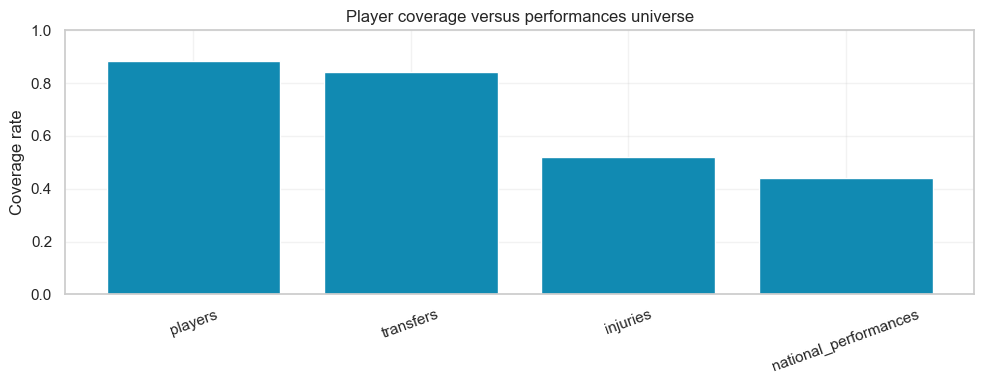

In [36]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(coverage["source"], coverage["coverage_rate"], color="#118AB2")
ax.set_ylim(0, 1)
ax.set_title("Player coverage versus performances universe")
ax.set_ylabel("Coverage rate")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()

In [37]:
performance_players = pd.DataFrame({"player_id": sorted(performance_player_ids)})
performance_players = performance_players.merge(
    players[["player_id", "player_name", "date_of_birth", "main_position", "current_club_name"]],
    on="player_id",
    how="left",
)

profile_gap = pd.DataFrame(
    [
        ["players in performances", performance_players.shape[0]],
        ["missing player_name", performance_players["player_name"].isna().sum()],
        ["missing date_of_birth", performance_players["date_of_birth"].isna().sum()],
        ["missing main_position", performance_players["main_position"].isna().sum()],
        ["missing current_club_name", performance_players["current_club_name"].isna().sum()],
    ],
    columns=["metric", "value"],
)

profile_gap

,metric,value
0,players in performances,8706
1,missing player_name,995
2,missing date_of_birth,996
3,missing main_position,995
4,missing current_club_name,995


In [38]:
performance_players.loc[performance_players["player_name"].isna()].head(20)

,player_id,player_name,date_of_birth,main_position,current_club_name
0,215,NaN,NaT,NaN,NaN
5,10471,NaN,NaT,NaN,NaN
6,11111,NaN,NaT,NaN,NaN
10,16911,NaN,NaT,NaN,NaN
15,20137,NaN,NaT,NaN,NaN
19,22686,NaN,NaT,NaN,NaN
22,24846,NaN,NaT,NaN,NaN
27,30677,NaN,NaT,NaN,NaN
45,43484,NaN,NaT,NaN,NaN
58,46552,NaN,NaT,NaN,NaN


## Conclusions

1. `performances` is the best table for defining the set of players and seasons.
2. `players` is useful for profiling, but it does not contain historical data: exercise caution with current club, value and contract.
3. `transfers` appears to be accurate in terms of dates and transfer types, but contains category changes that will need to be excluded from the target.
4. Injuries and international call-ups have a usable event-level granularity, provided you strictly filter out data prior to the transfer window...